# Optimizing a 14-day CHO fed-batch process to maximize an IgG1 mAb titer.

## 1. The "Black Box"
Here it is shown a simulated, "real-world" CRO project and the process of the mathematical logic behind it. 
## Phase 1: The Screening Protocol (Finding the Drivers)
### The Objective: 
You have 5 parameter "dials" you can turn, but you only have the budget/time to run 19 shake flasks. You need to know which dials actually affect the titer.
The Factors & Ranges:
1. Temperature Shift ($X_1$): 32 °C to 38 °C (Shift happens on Day 5)
2. pH Setpoint ($X_2$): 6.8 to 7.4
3. Feed Start Day ($X_3$): Day 3 to Day 5
4. Glucose Target ($X_4$): 2 g/L to 6 g/L
5. Sodium Butyrate Addition ($X_5$): 0 mM to 2 mM (A known transcription enhancer, but highly toxic)

### The Protocol:
Instead of testing every combination ($2^5 = 32$ runs), you use a Resolution V Fractional Factorial Design ($2^{5-1} = 16$ runs) plus 3 center points (all dials set exactly in the middle). Total = 19 runs.The Abstract Rationale:At this stage, you are assuming the biological landscape is flat but tilted. You are casting a wide net to see which direction the tilt goes. The center points act as your biological sanity check—if the 3 center point flasks have wildly different titers, your assay is too noisy to trust any math.

### 📐 Analyzing Phase 1: Applying the First-Degree (Linear) Equation
After 14 days, you measure the titer and feed the data into your ML/Statistical software. The software fits a First-Order Model:$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_4 + \beta_5 X_5$$
How to read the mathematical output:
- The $\beta$ Coefficients (Effect Size): The software returns a $\beta_5$ (Sodium Butyrate) of $-0.02$. This tells you the slope is basically zero; adding this chemical did nothing useful for your specific CHO clone. It returns a $\beta_3$ (Feed Start) of $0.1$, which is also negligible.
- The Big Drivers: However, $\beta_1$ (Temp Shift) is heavily negative (e.g., $-1.5$) and $\beta_2$ (pH) is heavily positive (e.g., $+2.1$).
- The Actionable Decision: You mathematically prove that Feed Start and NaBu are irrelevant noise. You drop them from the next phase to save money, setting them to convenient constants. You keep Temp, pH, and Glucose.
## Phase 2: The Optimization Protocol (Finding the Peak)
### The Objective: 
You know Temp, pH, and Glucose are the heavy hitters. Now you need to map the exact curvature of the biological mountain to find the peak titer.
The Factors (Zooming in):
1. Temperature Shift ($X_1$): 34 °C to 37.4 °C
2. pH Setpoint ($X_2$): 6.8 to 7.4
3. Glucose Target ($X_3$): 4 g/L to 6.5 g/L (Shifted up based on Phase 1 trends)
### The Protocol: Central Composite Design (CCD). 
This requires 8 "cube" points (the corners), 6 "star" points (pushing each variable slightly past its limits, e.g., Temp to 30°C and 36°C), and 3 center points. Total = 17 runs.
The Abstract Rationale:You are no longer assuming the landscape is a flat, tilted plane. You know there is a peak here somewhere, because if you push pH too high or Temp too low, the cells die and titer drops. The "star points" in the CCD are deliberately designed to capture this biological cliff, forcing the mathematical model to bend into a dome.
### 📐 Analyzing Phase 2: Applying the Second-Degree (Quadratic) Equation
You harvest the 17 bioreactors and fit the Second-Order Model:$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_{11} X_1^2 + \beta_{22} X_2^2 + \beta_{12} X_1 X_2 + \dots$$
How to read the mathematical output:
- The Quadratic Terms ($X^2$): Look at $\beta_{11}$ (Temp squared). If this coefficient is significantly negative, it means your 3D surface is concave facing downwards—you have successfully found a peak! If it were positive, it would mean you found a valley (a minimum), which is bad for titer.
- The Interaction Terms ($X_1 X_2$): Look at $\beta_{12}$ (Temp $\times$ pH). In biology, variables are coupled. A significant $\beta_{12}$ means that the ideal pH actually changes depending on what temperature you use. The quadratic model captures this twisted synergy perfectly; the linear model from Phase 1 was completely blind to it.
## Phase 3: The Objective Function Validation
### The Protocol: You have a fully trained quadratic equation.
This equation is now your synthetic objective function. You run a quick Python script using an optimization library (like scipy.optimize) to find the exact mathematical maximum of that equation.The math says: Max Titer of 6.5 g/L will be achieved at 37.3°C, pH 6.0, and 3 g/L Glucose.
### The Final Step:
You go back into the lab and run one final validation bioreactor at exactly 37.3°C, pH 6.0, and 3.0 g/L Glucose.If the physical bioreactor yields 7.5 g/L, congratulations! Your data-driven surrogate model perfectly captured the manifold of the biological system.If it yields 2.0 g/L, your model overfit the noise, or you pushed the cells into a biological regime where quadratic math breaks down.
## Bioprocess DoE Simulation Script
Below is a complete, run-able Python script that simulates an entire CRO project. 

To make this work, we will first code a "Secret Ground Truth" function. This represents the actual, physical CHO cell inside the bioreactor—the true biological manifold that we are trying to discover. Then, we will act as the data scientists, using scikit-learn and scipy to build our DoE, train our models, and find the peak.

In [2]:
# Importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

### 0.THE SECRET BIOLOGY (The "True" Manifold)
This is the physical reality of our CHO clone.
In real life, we don't know this equation; we only get to see the output (titer) after running a 14-day bioreactor.
Variables: `[Temp, pH, Feed_Start, Glucose, NaBu]`

In [1]:
def true_bioreactor(X):
    Temp, pH, FS, Gl, NaBu = X[:, 0], X[:, 1], X[:, 2], X[:, 3],X[:, 4]

    # The true peak is hidden at: Temp=32.8, pH=6.95, Glucose=5.5
    # Feed Start (FS) and NaBu have tiny coefficients (noise)
    titer = (
    6.5 - 0.8*(Temp-36.8)**2 - 2.5*(pH-6.8)**2 - 0.4*(Gl-5.5)**2 + 0.6*(Temp-36.8)*(pH-6.8) + 0.01*FS - 0.03*NaBu
    )

    # Add Biological/assay noise
    noise = np.random.normal(0, 0.1, size=len(Temp))

    # Titer cannot drop below  g/L in reality
    return np.maximum(0, titer + noise)

### Phase 1: Screening (Finding the Drivers)

In [5]:
print("--- PHASE 1: SCREENING (Linear Model) ---\n")

# We generate random experimental points within our wide screening ranges.
# In a real DoE, these would be strictly structured (Fractional Factorial), 
# but random uniform sampling serves the same ML purpose here.

np.random.seed(5)
n_screening_runs = 20
X_screen = np.column_stack((
    np.random.uniform(32, 38, n_screening_runs),     # X1: Temp
    np.random.uniform(6.6, 7.4, n_screening_runs),   # X2: pH
    np.random.uniform(3, 5, n_screening_runs),       # X3: Feed Start (FS)
    np.random.uniform(2, 6, n_screening_runs),       # X4: Glucose (Gl)
    np.random.uniform(0, 2, n_screening_runs),       # X5: Sodium Butirate (NaBu)
))

### Prepare the scale of the data using the 'StandatdScaler()' function. ###
scaler = StandardScaler()

# Fit the scaler to your screening data AND transform it in one step
X_screen_scaled = scaler.fit_transform(X_screen)

# Run the "real experiments" to get the y_values from the secret biology - The "ground truth"
y_screen = true_bioreactor(X_screen)

# Fit a First-Order (Linear) Model to see what matters
linear_model = LinearRegression()
linear_model.fit(X_screen_scaled, y_screen)

features = ['Temp', 'pH', 'Feed_Start', 'Glucose', 'NaBu']
features_p = np.asarray(features)
coefs = linear_model.coef_
for features, coef in zip(features, coefs):
    print(f'Effect for {features}: {coef:.3f}')

--- PHASE 1: SCREENING (Linear Model) ---

Effect for Temp: 1.978
Effect for pH: -0.303
Effect for Feed_Start: 0.016
Effect for Glucose: 0.576
Effect for NaBu: 0.079



DATA VISUALIZATION:


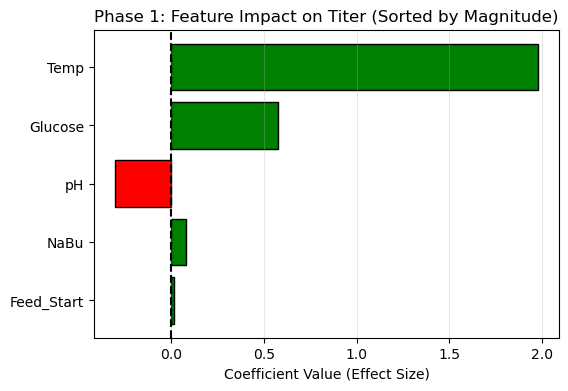


Decision: Feed_Start and NaBu have negligible slopes <= |0.15|. We drop them!
We will move to Phase 2 with only Temp, pH, and Glucose.



In [6]:
print("\nDATA VISUALIZATION:")

# Sort by absolute value to find the most impactful drivers
sort_indices = np.argsort(np.abs(coefs)) # Sort the index of the values from minor to maximum (absolute values)
sorted_features = features_p[sort_indices] # Sort the values based on the sort_indices
sorted_coefs = coefs[sort_indices]

# Determine colors: Green for positive impact, Red for negative impact
colors = ['green' if c > 0 else 'red' for c in sorted_coefs]

# Create a Bar Chart Pareto-style

plt.figure(figsize=(6,4))
plt.barh(sorted_features, sorted_coefs, color=colors, edgecolor='black')
plt.title('Phase 1: Feature Impact on Titer (Sorted by Magnitude)')
plt.xlabel('Coefficient Value (Effect Size)')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--') # Add a zero-line for reference
plt.grid(axis='x', alpha=0.3)
plt.show()

print("\nDecision: Feed_Start and NaBu have negligible slopes <= |0.15|. We drop them!")
print("We will move to Phase 2 with only Temp, pH, and Glucose.\n")

### Phase 2: Optimization (Finding the Peak)

In [15]:
print("--- PHASE 2: OPTIMIZATION (Quadratic Model) ---")

# We desing an experiment focusing only in the top 3 drivers (Temp, pH and Glucose).
# We zoom our ranges slightly based on Phase 1 insights.
n_opt_runs = 30
X_opt_3D = np.column_stack((
    np.random.uniform(34, 37.4, n_opt_runs), # X1: Temp
    np.random.uniform(6.8, 7.4, n_opt_runs), # X2: pH
    np.random.uniform(4, 6.5, n_opt_runs),   # X3: Glucose
))

# To run the 'true_bioreactor', we must plug in constants for the dropped variables
X_opt_full = np.column_stack((
    X_opt_3D, 
    np.full(n_opt_runs, 4.0), # Constant Feed Start at Day 4
    np.full(n_opt_runs, 0.5)  # Constant NaBu at 0.5 mM
))
# Run the Phase 2 experiments
y_opt = true_bioreactor(X_opt_full)

# Create the Quadratic equation: Polynomial features up to degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)

# Use the tool to transform the 3D data into 9D quadratic data
# IMPORTANT: Make sure you are using .fit_transform() here!
X_opt_poly = poly.fit_transform(X_opt_3D)

# Train the Synthetic Objective Function (Quadratic Model)
quadratic_model = LinearRegression()
quadratic_model.fit(X_opt_poly, y_opt)

# Print a key quadratic coefficient to prove we found a peak (downward curvature)

# Get the exact names of the 9 columns created by PolynomialFeatures
feature_names = poly.get_feature_names_out(['Temp', 'pH', 'Glucose'])
print("\n-DIAGNOSTIC: SCANNING ALL CURVATURES-")
# Zip the names and the trained weights together, just like we did in Phase 1
for name, weight in zip(feature_names, quadratic_model.coef_):
    # We only want to look at the squared terms (they contain '^2')
    if '^2' in name:
        if weight <0:
            print(f'{name} curvature: {weight:.3f} (Downward peak found! ✅)')
        else:
            print(f'{name} curvature: {weight:.3f} (Upward valley found... Warning! ❌)')
print("\nThe negative quadratic terms confirm we have mapped a peak, not a flat plane.")

--- PHASE 2: OPTIMIZATION (Quadratic Model) ---

-DIAGNOSTIC: SCANNING ALL CURVATURES-
Temp^2 curvature: -0.636 (Downward peak found! ✅)
pH^2 curvature: -0.940 (Downward peak found! ✅)
Glucose^2 curvature: -0.088 (Downward peak found! ✅)

The negative quadratic terms confirm we have mapped a peak, not a flat plane.


In [16]:
# ==========================================
# PHASE 3: THE OBJECTIVE FUNCTION VALIDATION
# ==========================================
print("--- PHASE 3: IN SILICO OPTIMIZATION ---")

# We wrap our trained ML model into an Objective Function
# Note: Scipy's 'minimize' finds the lowest point. To maximize titer, we return the NEGATIVE prediction.
def synthetic_objective_function(x_input):
    # x_input is a 1D array: [Temp, pH, Glucose]
    x_reshaped = x_input.reshape(1, -1)
    x_poly = poly.transform(x_reshaped)
    predicted_titer = quadratic_model.predict(x_poly)[0]
    return -predicted_titer # Negative for maximization

--- PHASE 3: IN SILICO OPTIMIZATION ---


In [18]:
# Initial guess for the optimizer (start somewhere in the middle)
initial_guess = [35.0, 7.0, 5.0]

# Bounds to ensure the math doesn't suggest impossible biology (e.g., pH 14)
bounds = [(31.0, 39.0), (6.0, 8.5), (3.0, 8.0)]

# Run the optimization algorithm (L-BFGS-B is great for bounded problems)
result = minimize(synthetic_objective_function, initial_guess, bounds=bounds, method='L-BFGS-B')

best_temp, best_ph, best_gluc = result.x
max_predicted_titer = -result.fun

print(f"Mathematical Optimizer found the peak at:")
print(f"  Temp: {best_temp:.2f} C")
print(f"  pH:   {best_ph:.3f}")
print(f"  Gluc: {best_gluc:.2f} g/L")
print(f"  Predicted Max Titer: {max_predicted_titer:.2f} g/L")

# The Final Validation
validation_run = np.array([[best_temp, best_ph, 4.0, best_gluc, 0.5]])
actual_titer = true_bioreactor(validation_run)[0]
print(f"\nLab Validation Titer at these coordinates: {actual_titer:.2f} g/L")

Mathematical Optimizer found the peak at:
  Temp: 37.36 C
  pH:   6.000
  Gluc: 3.00 g/L
  Predicted Max Titer: 7.65 g/L

Lab Validation Titer at these coordinates: 1.79 g/L


--- PHASE 4: GENERATING VISUALIZATION ---
Visualization generated. Look for the red star at the peak of the contours.


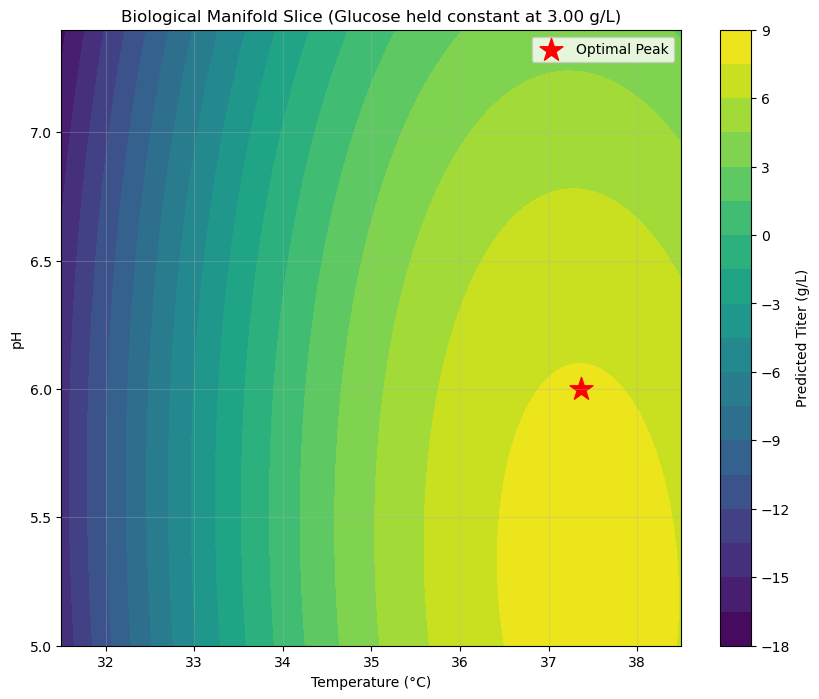

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# PHASE 4: VISUALIZING THE MANIFOLD SLICE
# ==========================================
print("--- PHASE 4: GENERATING VISUALIZATION ---")

# 1. Define the ranges for our 2D slice (Temp vs pH)
t_range = np.linspace(31.5, 38.5, 100) # 100 points across the Temp range
p_range = np.linspace(5.0, 7.4, 100) # 100 points across the pH range

# 2. Create a dense 2D grid (The map floor)
T_grid, P_grid = np.meshgrid(t_range, p_range)

# 3. Create the input data array for the model.
# We must reshape our grid points to fit (10000 runs, 3 variables)
X_slice_3D = np.column_stack((
    T_grid.ravel(), 
    P_grid.ravel(), 
    # CRITICAL SLICE: We hold Glucose constant at its optimal value everywhere
    np.full(T_grid.size, best_gluc) 
))

# 4. Use the trained "White Box" pipeline to predict titers across the slice
# Note: These variable names 'poly' and 'quadratic_model' must exist from previous cells
X_slice_poly = poly.transform(X_slice_3D)
y_slice_pred = quadratic_model.predict(X_slice_poly)

# 5. Reshape the predictions back into the grid shape for plotting
Titer_grid = y_slice_pred.reshape(T_grid.shape)

# 6. Generate the Plot
plt.figure(figsize=(10, 8))

# Create color-filled contours (The manifold surface)
contour = plt.contourf(T_grid, P_grid, Titer_grid, levels=20, cmap='viridis')
plt.colorbar(contour, label='Predicted Titer (g/L)')

# Mark the mathematical optimum we found with a red star
plt.scatter(best_temp, best_ph, color='red', marker='*', s=300, label='Optimal Peak')

# Add context
plt.title(f'Biological Manifold Slice (Glucose held constant at {best_gluc:.2f} g/L)')
plt.xlabel('Temperature (°C)')
plt.ylabel('pH')
plt.grid(alpha=0.3)
plt.legend()

print("Visualization generated. Look for the red star at the peak of the contours.")
plt.show()